In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from collections import Counter

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

print("NumPy version:", np.__version__)

NumPy version: 2.0.2


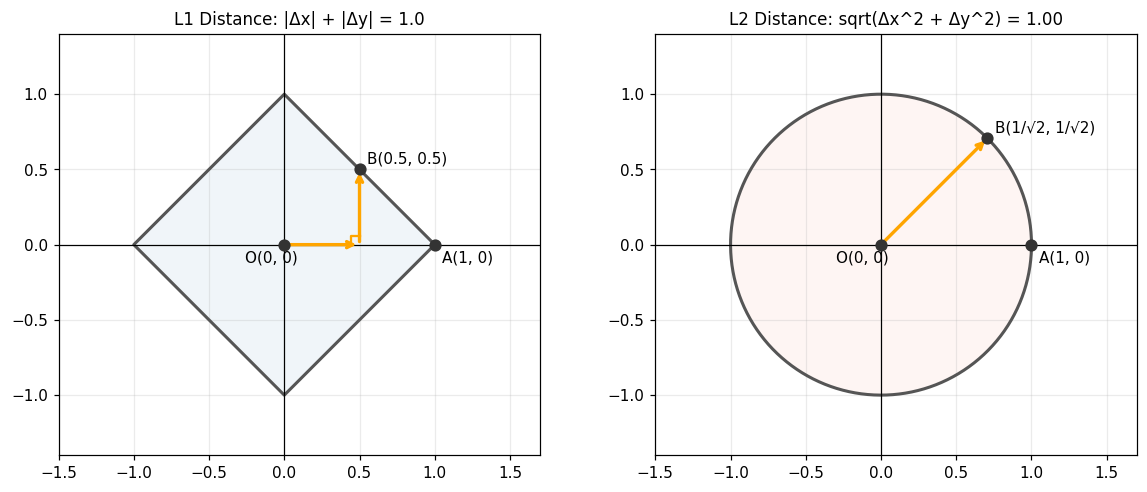

In [ ]:
## 거리함수

# L1 vs L2 distance: two-point illustration
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

r = 1.0
theta = np.linspace(0, 2 * np.pi, 300)

# Left: L1 (Manhattan)
ax = axes[0]
diamond_x = r * np.array([1, 0, -1, 0, 1])
diamond_y = r * np.array([0, 1, 0, -1, 0])
ax.plot(diamond_x, diamond_y, color="#555555", lw=2)
ax.fill(diamond_x, diamond_y, alpha=0.08, color="steelblue")

O = np.array([0.0, 0.0])
A = np.array([1.0, 0.0])
B = np.array([0.5, 0.5])

# Manhattan path: O -> (B.x, 0) -> B
mid = np.array([B[0], 0.0])
ax.annotate("", xy=mid, xytext=O,
arrowprops=dict(arrowstyle="->", color="orange", lw=2.2))
ax.annotate("", xy=B, xytext=mid,
arrowprops=dict(arrowstyle="->", color="orange", lw=2.2))

# Right-angle marker
sq = 0.055
ax.plot([mid[0]-sq, mid[0]-sq, mid[0]], [mid[1], mid[1]+sq, mid[1]+sq],
color="orange", lw=1.5)

for pt, label, dx, dy in [
  (O, "O(0, 0)", -0.26, -0.12),
  (A, "A(1, 0)", 0.05, -0.12),
  (B, "B(0.5, 0.5)", 0.05, 0.04)]:
  ax.plot(*pt, "o", color="#333", ms=7, zorder=5)
  ax.annotate(label, xy=pt, xytext=(pt[0]+dx, pt[1]+dy), fontsize=10)

l1 = abs(B[0]) + abs(B[1])
ax.set_title(f"L1 Distance: |{chr(916)}x| + |{chr(916)}y| = {l1:.1f}", fontsize=11)
ax.set_xlim(-1.5, 1.7); ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal"); ax.grid(True, alpha=0.25)
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)

# Right: L2 (Euclidean)
ax = axes[1]
circle_x = r * np.cos(theta)
circle_y = r * np.sin(theta)
ax.plot(circle_x, circle_y, color="#555555", lw=2)
ax.fill(circle_x, circle_y, alpha=0.08, color="salmon")

O2 = np.array([0.0, 0.0])
A2 = np.array([1.0, 0.0])
B2 = np.array([1/np.sqrt(2), 1/np.sqrt(2)])

# Euclidean path: straight line O -> B
ax.annotate("", xy=B2, xytext=O2,
arrowprops=dict(arrowstyle="->", color="orange", lw=2.2))

for pt, label, dx, dy in [
  (O2, "O(0, 0)", -0.30, -0.12),
  (A2, "A(1, 0)", 0.05, -0.12),
  (B2, "B(1/√2, 1/√2)", 0.05, 0.04)]:
  ax.plot(*pt, "o", color="#333", ms=7, zorder=5)
  ax.annotate(label, xy=pt, xytext=(pt[0]+dx, pt[1]+dy), fontsize=10)

l2 = np.sqrt(np.sum(B2**2))
ax.set_title(f"L2 Distance: sqrt({chr(916)}x^2 + {chr(916)}y^2) = {l2:.2f}", fontsize=11)
ax.set_xlim(-1.5, 1.7); ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal"); ax.grid(True, alpha=0.25)
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)

plt.tight_layout()
plt.show()

In [ ]:
## nn구현

class NearestNeighbor:
    """
    1-Nearest Neighbor Classifier (1-NN)
    - 학습: 데이터를 그냥 저장
    - 예측: 가장 가까운 학습 샘플 1개의 레이블 반환
    """
    def __init__(self):
        self.Xtr = None # 학습 데이터 (입력)
        self.ytr = None # 학습 데이터 (레이블)

    def train(self, X, y):
        """
        학습 단계 — 데이터를 기억한다.
        Parameters
        ----------
        X : ndarray, shape (N, D)
        N개의 학습 샘플, 각 샘플은 D차원 벡터
        y : ndarray, shape (N,)
        각 샘플의 레이블 (정수)
        """
        # KNN의 학습은 그냥 데이터를 저장
        # 실제로 아무 계산 x
        self.Xtr = X
        self.ytr = y

    def predict(self, X, metric='L1'):
        """
        예측 단계 — 각 테스트 샘플에 대해 가장 가까운 학습 샘플을 찾는다.
        Parameters
        ----------
        X : ndarray, shape (N_test, D)
        metric : 'L1' 또는 'L2'
        Returns
        -------
        Ypred : ndarray, shape (N_test,) 예측 레이블
        """
        num_test = X.shape[0]
        # 결과를 저장할 배열 (레이블과 같은 dtype으로!)
        Ypred = np.zeros(num_test, dtype=self.ytr.dtype)
        for i in range(num_test): # Python 3에서는 xrange 대신 range 사용

            # ── 거리 계산 ────────────────────────────────────────────────
            # self.Xtr : (N_train, D)
            # X[i, :] : (D,) — 현재 테스트 샘플
            # self.Xtr - X[i, :] : 브로드캐스팅으로 (N_train, D) 형태
            if metric == 'L1':
                # L1 거리: 차이의 절댓값을 차원 방향(axis=1)으로 합산
                distances = np.sum(np.abs(self.Xtr - X[i, :]), axis=1)
            else: # L2
                # L2 거리: 차이의 제곱합의 제곱근
                distances = np.sqrt(np.sum((self.Xtr - X[i, :]) ** 2, axis=1))

            # ── 최근접 이웃 찾기 ─────────────────────────────────────────
            # distances: (N_train,) 벡터
            # argmin: 가장 작은 값의 인덱스를 반환
            min_index = np.argmin(distances)

            # ── 레이블 할당 ──────────────────────────────────────────────
            # 가장 가까운 학습 샘플의 레이블을 그대로 사용
            Ypred[i] = self.ytr[min_index]
        return Ypred


In [ ]:
# ── 간단한 테스트 ─────────────────────────────────────────────────────────

# 학습 데이터: 2차원 점 5개, 레이블 0 또는 1
X_train_simple = np.array([
[1.0, 2.0], # class 0
[1.5, 1.8], # class 0
[5.0, 8.0], # class 1
[8.0, 8.0], # class 1
[1.0, 0.6], # class 0
])
y_train_simple = np.array([0, 0, 1, 1, 0])

# 테스트 데이터: 레이블을 예측하고 싶은 새 데이터
X_test_simple = np.array([
[1.2, 1.5], # (0, 0) 근처 → 예측: 0
[7.0, 7.5], # (1, 1) 근처 → 예측: 1
])
nn_clf = NearestNeighbor()
nn_clf.train(X_train_simple, y_train_simple)
preds = nn_clf.predict(X_test_simple, metric='L1')

print("예측 결과:", preds)
print("예상 정답: [0, 1]")

예측 결과: [0 1]
예상 정답: [0, 1]


In [24]:
## K-NN으로 확장

class KNNClassifier:
    """
    K-Nearest Neighbor Classifier
    Parameters
    ----------
    k : int, 이웃의 수 (기본값 1)
    metric : 'L1' 또는 'L2'
    """
    def __init__(self, k=1, metric='L2'):
        self.k = k
        self.metric = metric
        self.Xtr = None
        self.ytr = None

    def train(self, X, y):
        """학습: 데이터를 기억하는 것이 전부"""
        self.Xtr = X.astype(np.float64) # 계산 정확도를 위해 float으로
        self.ytr = y

    def _compute_distances(self, X):
        """
        테스트 데이터 X와 모든 학습 데이터 사이의 거리 행렬을 계산합니다.
        Returns
        -------
        dists : ndarray, shape (N_test, N_train)
        dists[i, j] = 테스트 i번째와 학습 j번째 사이의 거리
        """
        X = X.astype(np.float64)
        if self.metric == 'L1':
            # 브로드캐스팅 활용:
            # X[:, None, :] : (N_test, 1, D)
            # self.Xtr[None,:,:]: (1, N_train, D)
            # 차이 : (N_test, N_train, D) → axis=2로 합산
            dists = np.sum(np.abs(X[:, None, :] - self.Xtr[None, :, :]), axis=2)
        else: # L2
            # L2: 제곱 전개로 계산 (벡터화 최적화)
            # ||a - b||² = ||a||² - 2a·b^T + ||b||²
            X_sq = np.sum(X ** 2, axis=1, keepdims=True)
            Xtr_sq = np.sum(self.Xtr ** 2, axis=1, keepdims=True) # (N_train, 1)
            cross = X @ self.Xtr.T # (N_test, N_train)
            # (N_test, N_train)
            # 수치 오차로 인한 음수 방지를 위해 clip
            dists = np.sqrt(np.clip(X_sq + Xtr_sq.T - 2 * cross, 0, None))
        return dists # (N_test, N_train)

    def predict(self, X):
        """
        예측: 각 테스트 샘플에 대해 K개의 이웃을 찾아 다수결 투표
        Returns
        -------
        Ypred : ndarray, shape (N_test,)
        """
        ##############################4-NN classifier을 구현해보세요########################################
        # ① 거리 행렬 계산 (N_test × N_train)
        dists = self._compute_distances(X)
        num_test = X.shape[0]
        Ypred = np.zeros(num_test, dtype=self.ytr.dtype)
        # ② 거리 기준으로 정렬 후 상위 K개 인덱스 추출
        # argsort: 오름차순 정렬 시 각 값의 원래 인덱스를 반환
        for i in range(num_test):
            sorted_indices = np.argsort(dists[i])
            k_nearest_indices = sorted_indices[:self.k]
            # ③ K개 이웃의 레이블을 가져와서 다수결 투표
            k_nearest_labels = self.ytr[k_nearest_indices]
            # Counter: 각 레이블의 빈도를 셈. most_common(1)[0][0] = 가장 많은 레이블
            vote = Counter(k_nearest_labels.tolist())
            Ypred[i] = vote.most_common(1)[0][0]
        #########################################################################################################
        return Ypred

    def score(self, X, y):
        """정확도(accuracy) 반환"""
        preds = self.predict(X)
        return np.mean(preds == y)

학습 데이터: (240, 2), 테스트 데이터: (60, 2)


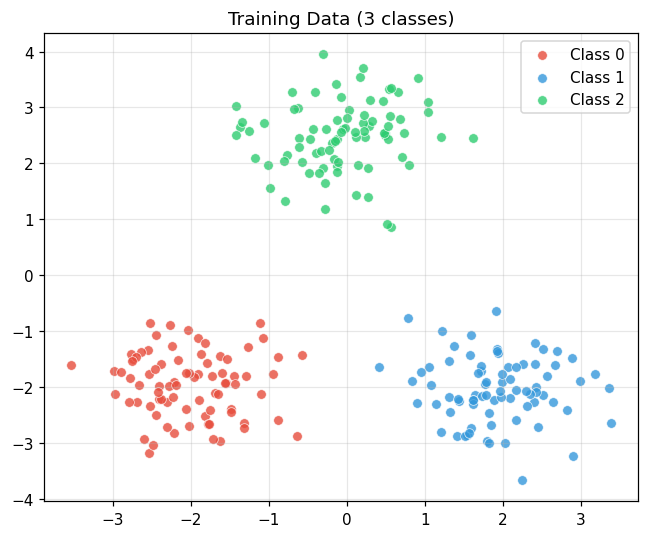

In [ ]:
# ── 실습 데이터 생성 ───────────────────────────────────────────────────────
def make_blobs(n=150, centers=3, std=0.6, seed=0):
    rng = np.random.RandomState(seed)
    c_list = [(-2, -2), (2, -2), (0, 2.5)]
    X_parts, y_parts = [], []
    n_each = n // centers
    for k, (cx, cy) in enumerate(c_list[:centers]):
        X_parts.append(rng.randn(n_each, 2) * std + [cx, cy])
        y_parts.append(np.full(n_each, k))
    return np.vstack(X_parts), np.concatenate(y_parts)
X_all, y_all = make_blobs(n=300, centers=3)
# 학습/테스트 분할 (80/20)
split = int(len(X_all) * 0.8)
idx = np.random.permutation(len(X_all))
X_train, y_train = X_all[idx[:split]], y_all[idx[:split]]
X_test, y_test = X_all[idx[split:]], y_all[idx[split:]]
print(f"학습 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")
# 데이터 시각화
colors = ['#e74c3c', '#3498db', '#2ecc71']
fig, ax = plt.subplots(figsize=(6, 5))
for k, c in enumerate(colors):
  m = y_train == k
  ax.scatter(X_train[m, 0], X_train[m, 1], c=c, s=40, alpha=0.8,
edgecolors='white', lw=0.5, label=f'Class {k}')
ax.set_title('Training Data (3 classes)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
# ── K=1, 3, 5 비교 ────────────────────────────────────────────────────────
for k in [1, 3, 5]:
  clf = KNNClassifier(k=k, metric='L2')
  clf.train(X_train, y_train)
  acc = clf.score(X_test, y_test)

  print(f"K={k} | Test Accuracy: {acc*100:.1f}%")

Counter({2: 1})
Counter({2: 1})
Counter({1: 1})
Counter({0: 1})
Counter({2: 1})
Counter({1: 1})
Counter({1: 1})
Counter({2: 1})
Counter({2: 1})
Counter({0: 1})
Counter({1: 1})
Counter({0: 1})
Counter({1: 1})
Counter({0: 1})
Counter({1: 1})
Counter({1: 1})
Counter({0: 1})
Counter({0: 1})
Counter({2: 1})
Counter({0: 1})
Counter({0: 1})
Counter({0: 1})
Counter({2: 1})
Counter({0: 1})
Counter({0: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
Counter({2: 1})
Counter({2: 1})
Counter({0: 1})
Counter({0: 1})
Counter({1: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
Counter({1: 1})
Counter({0: 1})
Counter({0: 1})
Counter({2: 1})
Counter({2: 1})
Counter({0: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
Counter({1: 1})
Counter({1: 1})
Counter({0: 1})
Counter({0: 1})
Counter({2: 1})
Counter({1: 1})
Counter({2: 1})
Counter({0: 1})
Counter({1: 1})
Counter({0: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
K=1 | Test Accuracy: 5.0%
Counter({2: 3}

Counter({2: 1})
Counter({2: 1})
Counter({1: 1})
Counter({0: 1})
Counter({2: 1})
Counter({1: 1})
Counter({1: 1})
Counter({2: 1})
Counter({2: 1})
Counter({0: 1})
Counter({1: 1})
Counter({0: 1})
Counter({1: 1})
Counter({0: 1})
Counter({1: 1})
Counter({1: 1})
Counter({0: 1})
Counter({0: 1})
Counter({2: 1})
Counter({0: 1})
Counter({0: 1})
Counter({0: 1})
Counter({2: 1})
Counter({0: 1})
Counter({0: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
Counter({2: 1})
Counter({2: 1})
Counter({0: 1})
Counter({0: 1})
Counter({1: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
Counter({1: 1})
Counter({0: 1})
Counter({0: 1})
Counter({2: 1})
Counter({2: 1})
Counter({0: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
Counter({1: 1})
Counter({1: 1})
Counter({0: 1})
Counter({0: 1})
Counter({2: 1})
Counter({1: 1})
Counter({2: 1})
Counter({0: 1})
Counter({1: 1})
Counter({0: 1})
Counter({1: 1})
Counter({2: 1})
Counter({1: 1})
Counter({2: 5})
Counter({2: 5})
Counter(

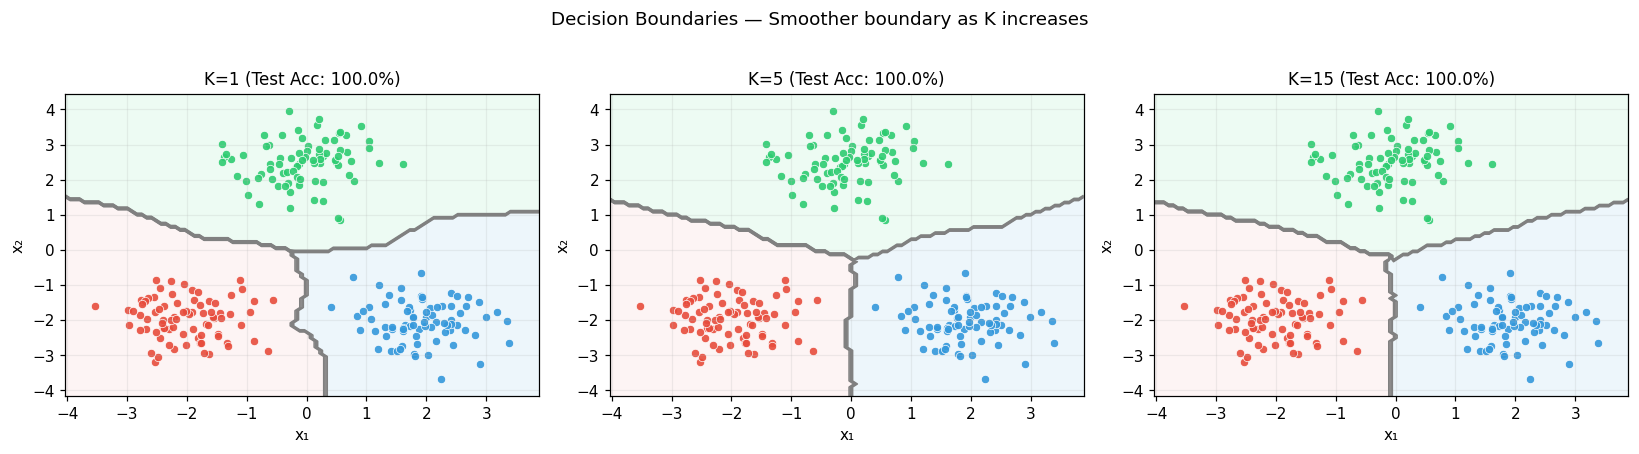

In [23]:
## Decision Boundary 시각화
import sys
import os
import contextlib

def plot_decision_boundary(clf, X, y, ax, title=''
, resolution=100):
    """Decision Boundary를 컬러맵으로 시각화"""
    cmap_bg = ListedColormap(['#fce4e4', '#d4e9f7', '#d4f5e2'])
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
    np.linspace(y_min, y_max, resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # 예측 중 발생하는 'Counter' 출력을 억제하기 위해 stdout을 리디렉션합니다.
    with contextlib.redirect_stdout(open(os.devnull, 'w')):
        Z = clf.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='gray', linewidths=1.0)
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    for k, c in enumerate(colors[:len(np.unique(y))]):
        m = y == k
        ax.scatter(X[m, 0], X[m, 1], c=c, s=30, edgecolors='white',
        lw=0.5, alpha=0.9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [1, 5, 15]):
    clf = KNNClassifier(k=k, metric='L2')
    clf.train(X_train, y_train)
    acc = clf.score(X_test, y_test)
    plot_decision_boundary(clf, X_train, y_train, ax,
    title=f'K={k} (Test Acc: {acc*100:.1f}%)')
plt.suptitle('Decision Boundaries — Smoother boundary as K increases',
fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

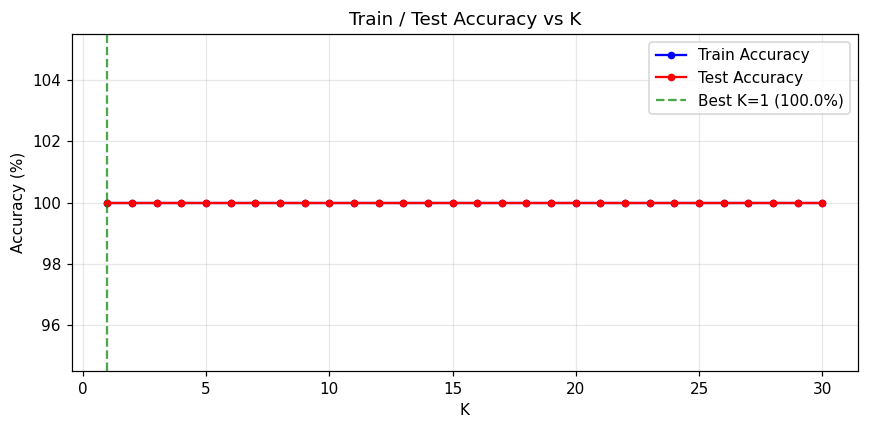


K=1 Train: 100.0% Test: 100.0% (Overfitting!)
Best K=1 Test: 100.0%


In [26]:
## K에 따른 민감도 분석

k_values = list(range(1, 31))
train_accs, test_accs = [], []
for k in k_values:
    clf = KNNClassifier(k=k, metric='L2')
    clf.train(X_train, y_train)
    train_accs.append(clf.score(X_train, y_train))
    test_accs.append(clf.score(X_test, y_test))
best_k = k_values[np.argmax(test_accs)]
best_acc = max(test_accs)
plt.figure(figsize=(8, 4))
plt.plot(k_values, [a * 100 for a in train_accs], 'b-o', markersize=4,
label='Train Accuracy')
plt.plot(k_values, [a * 100 for a in test_accs], 'r-o', markersize=4,
label='Test Accuracy')
plt.axvline(best_k, color='green', ls='--', alpha=0.7,
label=f'Best K={best_k} ({best_acc*100:.1f}%)')
plt.xlabel('K'); plt.ylabel('Accuracy (%)')
plt.title('Train / Test Accuracy vs K')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"\nK=1 Train: {train_accs[0]*100:.1f}% Test: {test_accs[0]*100:.1f}% (Overfitting!)")
print(f"Best K={best_k} Test: {best_acc*100:.1f}%")

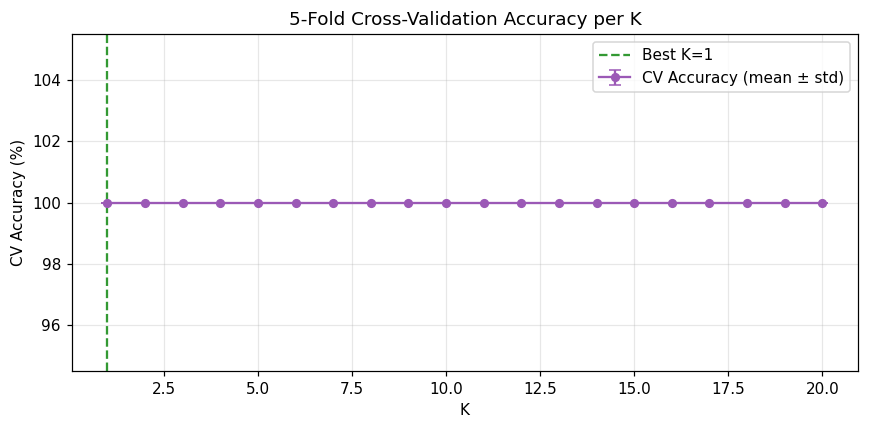

Best K selected by Cross-Validation: 1
Final Test Accuracy (K=1): 100.0%


In [29]:
## Cross-Validation으로 K 선택

def cross_validate_knn(X, y, k_values, n_folds=5, metric='L2'):
"""
K-Fold Cross-Validation으로 각 K의 검증 정확도를 계산합니다.
Parameters
----------
X : 학습 데이터 입력
y : 학습 데이터 레이블
k_values : 탐색할 K 값 목록
n_folds : fold 수 (기본 5)
Returns
-------
cv_scores : dict {k: [fold별 정확도 리스트]}
"""
N = len(X)
fold_size = N // n_folds
# 데이터를 섞어서 n_folds개의 fold로 나누기
indices = np.random.permutation(N)
folds_X = []
folds_y = []
for f in range(n_folds):
start = f * fold_size
end = start + fold_size if f < n_folds - 1 else N
folds_X.append(X[indices[start:end]])
folds_y.append(y[indices[start:end]])
cv_scores = {k: [] for k in k_values}
for k in k_values:
for val_fold in range(n_folds):
# validation: val_fold번째 fold
X_val = folds_X[val_fold]
y_val = folds_y[val_fold]
# train: 나머지 fold들
X_tr = np.vstack([folds_X[f] for f in range(n_folds) if f != val_fold])
y_tr = np.concatenate([folds_y[f] for f in range(n_folds) if f != val_fold])
clf = KNNClassifier(k=k, metric=metric)
clf.train(X_tr, y_tr)
acc = clf.score(X_val, y_val)
cv_scores[k].append(acc)
return cv_scores
# ── Cross-Validation 실행 ───────────────────────────────────────────────
k_search = list(range(1, 21))
cv_scores = cross_validate_knn(X_train, y_train, k_values=k_search, n_folds=5)
cv_means = [np.mean(cv_scores[k]) for k in k_search]
cv_stds = [np.std(cv_scores[k]) for k in k_search]
best_k_cv = k_search[np.argmax(cv_means)]
plt.figure(figsize=(8, 4))
plt.errorbar(k_search, [m * 100 for m in cv_means],
yerr=[s * 100 for s in cv_stds],
fmt='-o', markersize=5, capsize=4,
color='#9b59b6', label='CV Accuracy (mean ± std)')
plt.axvline(best_k_cv, color='green', ls='--', alpha=0.8,
label=f'Best K={best_k_cv}')
plt.xlabel('K'); plt.ylabel('CV Accuracy (%)')
plt.title('5-Fold Cross-Validation Accuracy per K')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Best K selected by Cross-Validation: {best_k_cv}")
# Final test with selected K
final_clf = KNNClassifier(k=best_k_cv, metric='L2')
final_clf.train(X_train, y_train)
final_acc = final_clf.score(X_test, y_test)
print(f"Final Test Accuracy (K={best_k_cv}): {final_acc*100:.1f}%")

In [36]:
## CIFAR-10 스타일 실험

# ── 가상 이미지 데이터 (32×32×3 → 3072차원 벡터) ────────────────────────
np.random.seed(7)
N_tr, N_te, D_img = 200, 40, 32 * 32 * 3
n_classes = 5
# 3072차원
# 클래스마다 다른 평균값을 가진 이미지 데이터
X_img_tr = np.vstack([
np.random.randn(N_tr // n_classes, D_img) + np.random.randn(D_img) * 0.5
for _ in range(n_classes)
])
y_img_tr = np.repeat(np.arange(n_classes), N_tr // n_classes)
X_img_te = np.vstack([
np.random.randn(N_te // n_classes, D_img) + np.random.randn(D_img) * 0.5
for _ in range(n_classes)
])
y_img_te = np.repeat(np.arange(n_classes), N_te // n_classes)
print(f"Training images: {X_img_tr.shape} (each row = one flattened image)")
# 전처리: 평균 정규화 (Mean Normalization)
mean = X_img_tr.mean(axis=0) # 픽셀별 평균
X_img_tr_norm = X_img_tr - mean
X_img_te_norm = X_img_te - mean
# L1 vs L2 비교
print("\n[After normalization]")
for metric in ['L1', 'L2']:
    for k in [1, 3, 5]:
        clf = KNNClassifier(k=k, metric=metric)
        clf.train(X_img_tr_norm, y_img_tr)
        acc = clf.score(X_img_te_norm, y_img_te)
        print(f" {metric} K={k}: {acc*100:.1f}%")

Training images: (200, 3072) (each row = one flattened image)

[After normalization]
 L1 K=1: 10.0%
 L1 K=3: 12.5%
 L1 K=5: 20.0%
 L2 K=1: 12.5%
 L2 K=3: 17.5%
 L2 K=5: 25.0%


In [37]:
# 연습문제1

import numpy as np

X_train = np.array([[1,1], [2,3], [5,2], [4,5], [6,6]])
y_train = np.array([0,0,1,1,1])

x_test = np.array([3,3])

# L1 거리 (Manhattan)
l1_distances = np.sum(np.abs(X_train - x_test), axis=1)

# L2 거리 (Euclidean)
l2_distances = np.sqrt(np.sum((X_train - x_test)**2, axis=1))

print("L1 distances:", l1_distances)
print("L2 distances:", l2_distances)

# K=1
k1_index = np.argsort(l2_distances)[:1]
k1_prediction = np.bincount(y_train[k1_index]).argmax()

# K=3
k3_index = np.argsort(l2_distances)[:3]
k3_prediction = np.bincount(y_train[k3_index]).argmax()

print("K=1 prediction:", k1_prediction)
print("K=3 prediction:", k3_prediction)

L1 distances: [4 1 3 3 6]
L2 distances: [2.82842712 1.         2.23606798 2.23606798 4.24264069]
K=1 prediction: 0
K=3 prediction: 1


In [39]:
# 연습문제2

import numpy as np

class KNNClassifier:
    def __init__(self, X_train):
        self.X_train = X_train

    def _compute_distances(self, X_test):
        # ||a||^2
        test_sq = np.sum(X_test**2, axis=1).reshape(-1, 1)

        # ||b||^2
        train_sq = np.sum(self.X_train**2, axis=1)

        # -2a^T b
        cross_term = -2 * np.dot(X_test, self.X_train.T)

        # 전체 거리 제곱
        dists_squared = test_sq + cross_term + train_sq

        # L2 distance
        dists = np.sqrt(dists_squared)

        return dists

# 예시 데이터
X_train = np.array([[1,1], [2,3], [5,2], [4,5], [6,6]])
X_test = np.array([[3,3]])

knn = KNNClassifier(X_train)

distances = knn._compute_distances(X_test)

print("L2 distances:")
print(distances)


L2 distances:
[[2.82842712 1.         2.23606798 2.23606798 4.24264069]]


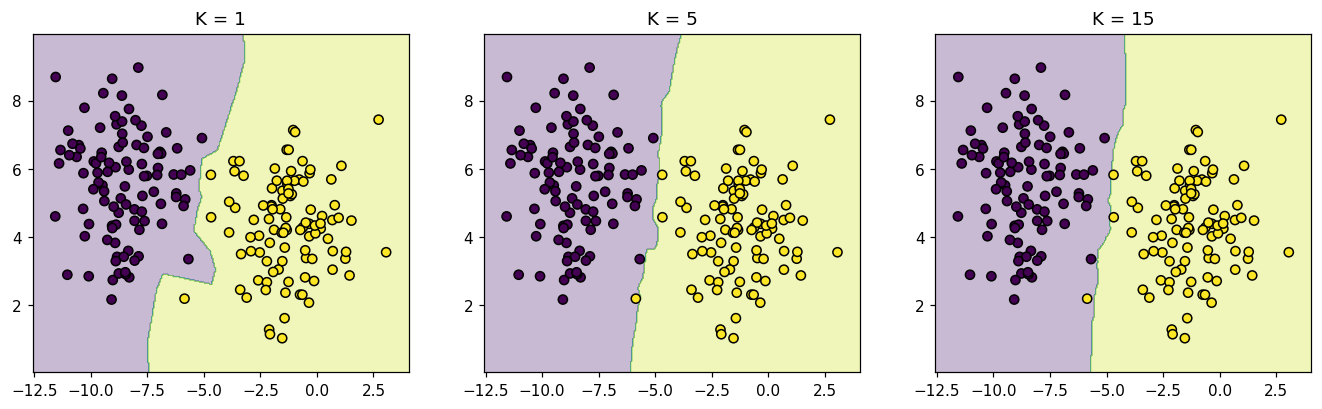

In [40]:
# 연습문제3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier

# 데이터 생성 (노이즈 포함)
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.5, random_state=7)

# Decision Boundary 시각화 함수
def plot_knn(k, X, y):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)

    # grid 생성
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors="k")
    plt.title(f"K = {k}")

# 그래프 출력
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plot_knn(1, X, y)

plt.subplot(1,3,2)
plot_knn(5, X, y)

plt.subplot(1,3,3)
plot_knn(15, X, y)

plt.show()

In [41]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# 데이터 로드
digits = load_digits()
X = digits.data
y = digits.target

# train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# K 후보
k_values = range(1, 21)

cv_scores = []

# Cross Validation
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

# 최적 K
best_k = k_values[np.argmax(cv_scores)]

print("Best K:", best_k)

# 최적 모델 학습
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)

# 테스트 정확도
test_accuracy = best_model.score(X_test, y_test)

print("Test Accuracy:", test_accuracy)

Best K: 1
Test Accuracy: 0.9777777777777777
